In [1]:
%reload_ext autoreload
%autoreload 2

In [131]:
import jax
import jax.numpy as jnp

import matplotlib.pyplot as plt

# load mplstyle file
plt.style.use('pyloric_black.mplstyle')

from flax import nnx

Duplicate key in file 'pyloric_black.mplstyle', line 65 ('savefig.facecolor    : black       # Ensures black background when saving')


In [132]:
from diffusion_mri_models import Dti, Ball, Stick, add_mri_noise

In [133]:
from sympy import jn


class BallAndStick(nnx.Module, experimental_pytree=True):
    
    def __init__(self,num_sticks: int, rngs):
        self.num_sticks = num_sticks
        self.num_components = 1 + num_sticks + 1 # Ball + Sticks + Noise
        # Ball parameters
        self.theta_ball = nnx.Param(jax.random.normal(rngs.next(), (1)))
        self.phi_ball = nnx.Param(jax.random.normal(rngs.next(), (1)))

        self.thetas_stick = []
        self.phis_stick = []
    
        for i in range(num_sticks):
            self.thetas_stick.append(nnx.Param(jax.random.normal(rngs.next(), (3))))
            #if i < num_sticks-1:
            self.phis_stick.append(nnx.Param(jax.random.normal(rngs.next(), (1))))

        self.theta_sigma = nnx.Param(jax.random.normal(rngs.next(), (1)))

        

    def __call__(self, component_mask, bvals, bvecs, rng):
        ball = Ball.from_theta(self.theta_ball.value)
        sticks = [Stick.from_theta(theta) for theta in self.thetas_stick]


        phi0 = self.phi_ball.value
        phi1 = self.phis_stick[0].value
        phi2 = self.phis_stick[1].value 
        
        phis = jnp.concatenate([phi0, phi1, phi2])
        phis = jnp.where(component_mask[:-1] == 0, -jnp.inf, phis)
        phis_normalized = jax.nn.softmax(phis)
        phis_normalized = jnp.where(component_mask[:-1] == 0, 0, phis_normalized)
        
        S_ball = ball.signal(bvals, bvecs) * phis_normalized[0]
        S_total = S_ball

        for i, stick in enumerate(sticks):
            S_total += stick.signal(bvals, bvecs)*phis_normalized[i+1]
            

        std = jax.nn.sigmoid(self.theta_sigma.value)*0.1 * component_mask[-1]
        S_noisy = add_mri_noise(rng,S_total, std)

        return S_noisy


In [20]:
import numpy as np
bvals = np.load('bvals.npy')
bvecs = np.load('bvecs.npy')

S_real = np.load("masked_data.npy")
b0_mask = bvals == 0

S0_real = np.mean(S_real[...,b0_mask], axis=-1, keepdims=True)
S_real = np.nan_to_num(S_real / S0_real)

/tmp/ipykernel_25527/2709049621.py:9: RuntimeWarning: divide by zero encountered in divide
  S_real = np.nan_to_num(S_real / S0_real)
/tmp/ipykernel_25527/2709049621.py:9: RuntimeWarning: invalid value encountered in divide
  S_real = np.nan_to_num(S_real / S0_real)


In [21]:
simulator = BallAndStick(2, nnx.Rngs(0))

# bvals = jnp.array([0]*10 + [1000]*90)
# bvecs = jax.random.normal(jax.random.key(1), (100,3))
component_mask = jnp.array([1]*simulator.num_components)
component_mask

Array([1, 1, 1, 1], dtype=int32)

In [27]:
component_mask = jnp.array([1,0,0,1])
s = simulator(component_mask, bvals, bvecs, jax.random.key(9))

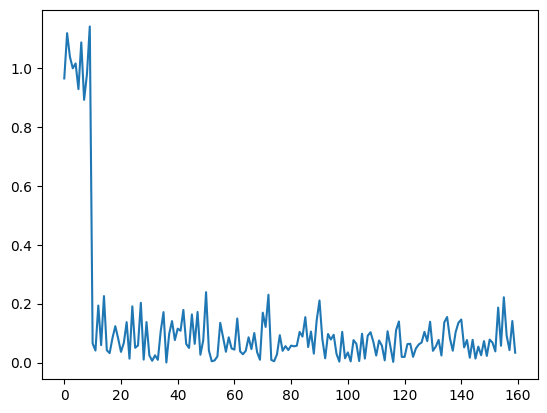

In [28]:
plt.plot(s)

In [29]:
graphdef, thetas = nnx.split(simulator, nnx.Param)
flat_thetas, unflatten = jax.flatten_util.ravel_pytree(thetas)


NUM_AQUISITIONS = len(bvals)

def generate_data(key):
    rng_component_mask, rng_params, rng_simulator = jax.random.split(key,3)
    component_mask = jax.random.bernoulli(rng_component_mask, 0.3, (simulator.num_components,))
    params = jax.random.normal(rng_params, flat_thetas.shape)
    params = unflatten(params)
    f = nnx.merge(graphdef, params)
    S = f(component_mask, bvals, bvecs, rng_simulator)
    return component_mask, params, S




In [30]:
from functools import partial


@partial(jax.jit, static_argnums=(1,))  
def batch_sampler(key, batch_size=512):
    keys = jax.random.split(key, batch_size)
    components, thetas, signal= jax.vmap(lambda k:generate_data(k))(keys)
    xs = signal.reshape((batch_size, -1))
    return components, thetas, xs

def train_data_generator(key, batch_size):
    while True:
        key, subkey = jax.random.split(key)
        yield batch_sampler(subkey, batch_size)

train_data = train_data_generator(jax.random.PRNGKey(0), 1024)

In [31]:
from models import ModelIdentificationDecoder, MLP

In [32]:
embedding_net = MLP([NUM_AQUISITIONS, 100,100], rngs=nnx.Rngs(0))
decoder = ModelIdentificationDecoder(100,100, rngs=nnx.Rngs(1), num_heads=4, num_layers=4, widening_factor=4, context_net=embedding_net)


class Model(nnx.Module, experimental_pytree=True):
    def __init__(self, num_components,decoder):
        self.decoder = decoder
        self.num_components = num_components
    def __call__(self, components, thetas, x_o):
        logits = self.decoder(components, x_o)
        return logits
    
    def sample_components(self,rng, num_samples,x_o):
        rngs = jax.random.split(rng, num_samples)
        return jax.vmap(self.decoder.sample, in_axes=(0,None,None))(rngs, x_o, self.num_components)

model = Model(4,decoder)
params = nnx.state(model, nnx.Param)

In [33]:
components, thetas, xs = next(train_data)

In [138]:
import optax 


scheduler = optax.cosine_onecycle_schedule(20_000, 1e-4)
optimizer = optax.adamw(scheduler)

@jax.jit
def loss_fn(params, data):
    nnx.update(model, params)
    components, thetas, xs = data

    logits = model(components,thetas, xs)

    loss_model_selection =  optax.sigmoid_binary_cross_entropy(logits, components).sum()


    return loss_model_selection

@jax.jit
def update(params, opt_state, data):
    grads = jax.grad(loss_fn)(params, data)
    updates, opt_state = optimizer.update(grads, opt_state, params=params)
    new_params = optax.apply_updates(params, updates)
    return new_params, opt_state



In [139]:
opt_state = optimizer.init(params)

In [140]:
for i in range(20_000):
    data = next(train_data)
    params, opt_state = update(params, opt_state, data)
    if i % 100 == 0:
        print(loss_fn(params, data))

553.7927
613.37524
578.98395
529.3163
583.3147
570.17456
564.4654
573.68176
600.6322
572.45435
639.937
571.63367
549.5702
595.0017
556.1996
518.0073
573.31665
570.8373
559.54065
536.6426
553.67444
576.4798
574.9809
552.0338
561.8409
549.565
592.8237
618.1395
536.5209
569.59033
563.3895
552.3894
537.71576
584.1746
571.9443
591.69885
579.2146
550.3485
515.0615
592.3843
568.5316
615.2039
554.9867
574.7524
561.7053
579.87836
561.04395
595.52966
577.47
584.27734
589.60864
561.9897
584.1875
512.78253
632.2251
590.75854
573.557
564.21027
620.0198
551.28613
597.91516
569.29626
579.2359
618.5154
528.22754
545.6537
555.8684
575.5807
525.65326
523.24915
516.70544
575.53125
582.3379
519.2282
592.55554
596.68677
999.0884
561.395
611.1421
542.89856
525.2049
624.46356
573.05426
567.19385
572.3696
597.86273
537.6977
547.1594
588.7666
539.4655
521.0577
602.3312
575.24713
536.64026
577.20337
553.9854
578.81177
571.2954
530.06726
520.606
542.8323
572.24335
525.32544
561.80994
570.714
561.349
547.38477
55

KeyboardInterrupt: 

In [141]:
nnx.update(model, params)

In [142]:
components, thetas, xs = next(train_data)

[False  True False  True]


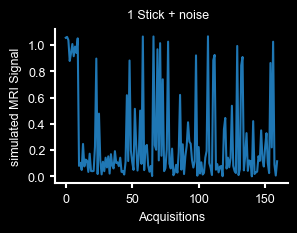

In [167]:
idx = 4
print(components[idx])
components_pred = model.sample_components(jax.random.PRNGKey(4),100, xs[idx])


fig = plt.figure(figsize=(3,2))
plt.ylabel("simulated MRI Signal")
plt.xlabel("Acquisitions")
plt.plot(xs[idx])

fig.suptitle("1 Stick + noise")
plt.show()

fig.savefig("figures/1_stick_noise.png")


In [168]:
components[idx]

Array([False,  True, False,  True], dtype=bool)

[False  True False  True] [0.   0.47 0.53 1.  ]


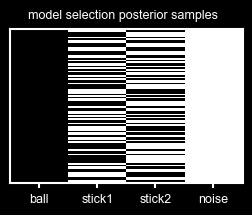

In [169]:
print(components[idx], components_pred.mean(0))

fig = plt.figure(figsize=(3,2))
plt.imshow(components_pred, aspect='auto', cmap="Greys_r")
# Turn of axis spines and ticks
plt.gca().spines['top'].set_visible(True)
plt.gca().spines['right'].set_visible(True)
plt.xticks([0,1,2,3],["ball", "stick1", "stick2", "noise"])
plt.yticks([])
fig.suptitle("model selection posterior samples")
fig.savefig("figures/model_selection_posterior.png", dpi=300)

In [ ]:
# Real data

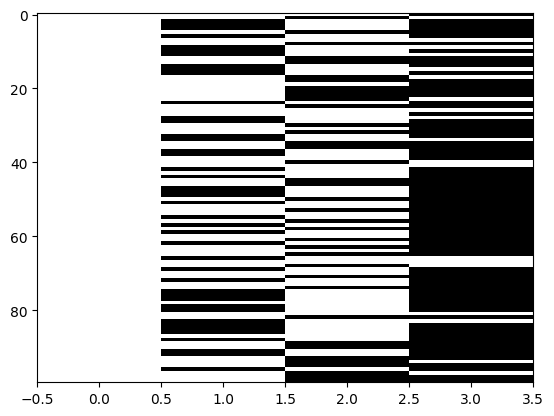

In [57]:
S_o_real = S_real[20,20,30]

components_pred = model.sample_components(jax.random.PRNGKey(4),100, S_o_real)
plt.imshow(components_pred, aspect='auto', cmap="Greys_r")

In [83]:
jax.clear_caches()

In [182]:
from sympy import comp


S_o_slice = S_real[:,:,20]

def infer_components(rng,S_o):
    components_pred = model.sample_components(rng,25, S_o)
    only_ball = components_pred[:,0] & ~(components_pred[:,1] | components_pred[:,2])
    ball_and_stick = components_pred[:,0] & (components_pred[:,1] | components_pred[:,2])
    ball_and_stick_and_stick = components_pred[:,0] & components_pred[:,1] & components_pred[:,2]
    only_ball = jnp.mean(only_ball, axis=0)
    # only stick is c[1] xor c[2]
    only_stick = (components_pred[:,1] ^ components_pred[:,2]) & ~components_pred[:,0]
    only_stick = jnp.mean(only_stick, axis=0)
    ball_and_stick = jnp.mean(ball_and_stick, axis=0)
    ball_and_stick_and_stick = jnp.mean(ball_and_stick_and_stick, axis=0)
    return components_pred.mean(0), ball_and_stick, ball_and_stick_and_stick, only_ball, only_stick

rngs = jax.random.split(jax.random.key(0), S_o_slice.shape[:-1])
components_pred, ball_and_stick, ball_and_stick_and_stick, only_ball, only_stick =jax.vmap(jax.vmap(infer_components))(rngs,S_o_slice)

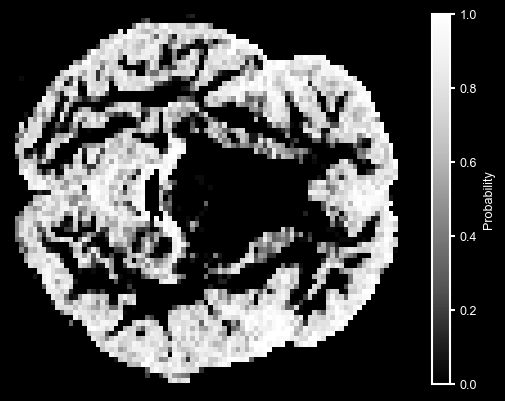

In [185]:
plt.imshow(only_ball, aspect='auto', cmap="Greys_r")
cbar = plt.colorbar()
cbar.set_label("Probability")
plt.axis('off')
plt.savefig("figures/only_ball_brain.png", dpi=300)

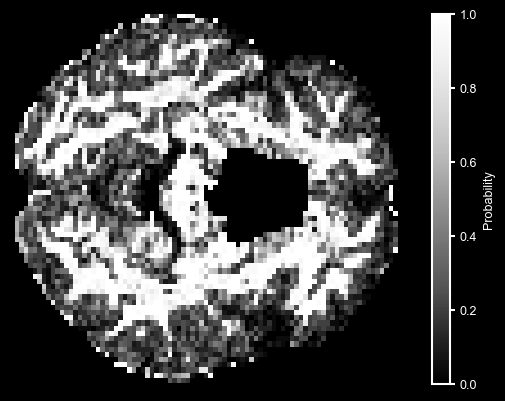

In [186]:
plt.imshow(ball_and_stick, aspect='auto', cmap="Greys_r")
cbar = plt.colorbar()
cbar.set_label("Probability")
plt.axis('off')
plt.savefig("figures/only_ball_and_stick_brain.png", dpi=300)

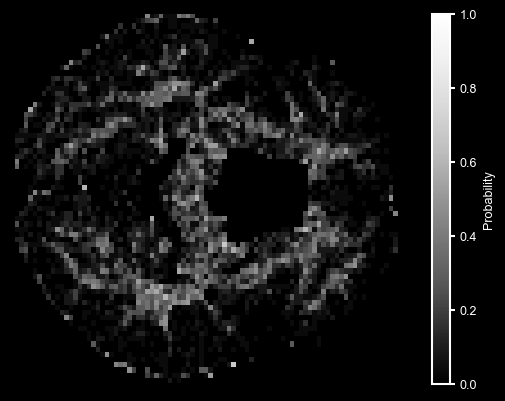

In [189]:
plt.imshow(ball_and_stick_and_stick, aspect='auto', cmap="Greys_r", vmin=0, vmax=1)
cbar = plt.colorbar()
cbar.set_label("Probability")
plt.axis('off')
plt.savefig("figures/only_ball_and_stick_and_stick_brain.png", dpi=300)

In [190]:
S_o_slice[...,0]